# **Holiday Mini Project 1**
---
Mini proyek yang dikerjakan selama masa liburan, dengan tujuan untuk membuat masa liburan tetap produktif. Proyek pertama adalah tentang Machine Learning pada mata kuliah Pembelajaran Mesin dan Aplikasinya, mulai dari pra pemrosesan data hingga membangun sebuah model.

## **Data Preprocessing**
---
Dataset yang digunakan adalah Titanic Dataset by M Yasser H.
* Jenis tugas: Klasifikasi
* Tujuan: Membuat model untuk mengklasifikasikan mana penumpang yang selamat (1) dan tidak selamat (0)


### **Load Dataset**

In [66]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [67]:
import pandas as pd

df_titanic = pd.read_csv(path + "/Titanic-Dataset.csv")

### **Exploratory Data Analysis (EDA)**



#### **Data Understanding**

In [68]:
df_titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [69]:
df_titanic.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [70]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Deskripsi:
1. *PassengerId:* Nomor urut penumpang.
2. *Survived:* Kolom target, penumpang selamat (1) dan penumpang tidak selamat (0).
3. *Pclass:* Kelas tiket yang dibeli -> Menentukan prioritas penumpang, seperti akses mendapatkan sekoci.
4. *Name:* Nama penumpang.
5. *Sex:* Jenis kelamin penumpang -> Wanita diselamatkan terlebih dahulu.
6. *Age:* Umur penumpang -> Anak-anak dan orang tua diprioritaskan.
7. *SibSp (Siblings/Spouses):* Jumlah saudara kandung + pasangan yang ikut di dalam kapal.
8. *Parch (Parents/Children):* Jumlah orang tua + anak yang ikut di dalam kapal -> Gabungan kolom 7 dan 8 menunjukkan seberapa besar ukuran keluarga yang dibawa. Biasanya penumpang yang sendirian cenderung lebih gesit.
9. *Ticket:* Nomor tiket.
10. *Fare:* Harga tiket yang dibayar -> Berkaitan dengan kelas tiket.
11. *Cabin:* Nomor kamar/kabin -> Menunjukkan lokasi kamar penumpang di kapal. Apakah mungkin dek tertentu lebih dekat dengan sekoci atau tidak?
12. *Embarked:* Pelabuhan keberangkatan.

In [71]:
df_titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### **1) Perbandingan Penumpang Selamat dan Tidak Selamat**
---
Melihat perbandingan jumlah penumpang yang selamat dan tidak selamat. Apakah data balanced atau imbalanced?

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

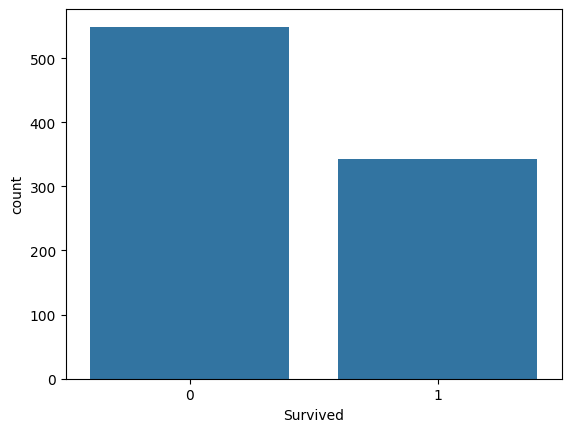

In [73]:
sns.countplot(df_titanic, x='Survived')

plt.show()

In [74]:
print(df_titanic['Survived'].value_counts()) # value_counts() -> menghitung jumlah masing-masing data pada sebuah kolom di dalam dataframe

Survived
0    549
1    342
Name: count, dtype: int64


Analisis:

Terlihat data imbalanced, jumlah penumpang yang tidak selamat (0) jauh lebih banyak daripada jumlah penumpang yang selamat (1). Hal ini dapat menyebabkan model cenderung memprediksi penumpang tidak selamat (0) karena model menjadi bias terhadap data target yang dominan.

##### **2) Analisis Keluarga**
---
Melihat korelasi kolom 'SibSp' dan 'Parch' dengan keselamatan penumpang. Apakah semakin banyak keluarga yang ada di dalam kapal akan membuat proses evakuasi menjadi semakin sulit atau malah sebaliknya?

**Feature Engineering**

Kita gabungkan kedua kolom 'SibSp' dan 'Parch' + 1 (diri sendiri) menjadi sebuah kolom/fitur baru, yaitu 'Total_Family_Members'.

In [75]:
total_family_members = df_titanic['Parch'] + df_titanic['SibSp'] + 1

print(total_family_members)

0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Length: 891, dtype: int64


In [76]:
df_titanic_copy = df_titanic.copy()

df_titanic_copy.insert(8, 'FamilySize', total_family_members)

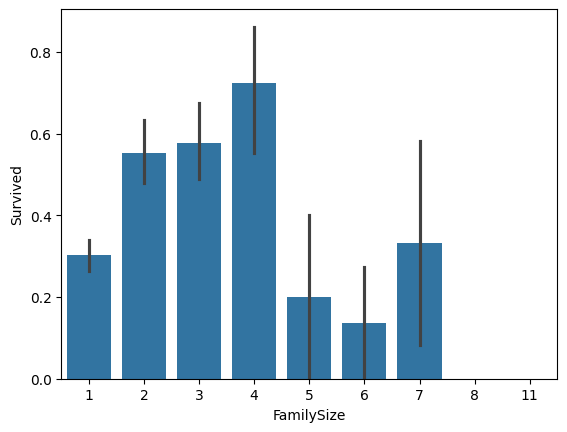

In [77]:
sns.barplot(df_titanic_copy, x='FamilySize', y='Survived')

plt.show()

Analisis:
* sns.barplot -> tidak menghitung jumlah data, tetapi menghitung rata-rata (mean) atau peluang.
* Sumbu Y (Survived): Angka 0,0 sampai dengan 1,0 adalah peluang penumpang selamat (1). Error bar -> Garis hitam di tengah yang menunjukkan seberapa yakin datanya, semakin panjang, semakin tidak yakin datanya (mungkin karena datanya sedikit).

Dapat kita lihat bahwa penumpang yang sendiri (tanpa membawa keluarga) memiliki peluang selamat sekitar 0,3 atau 30%. Penumpang yang membawa keluarga berjumlah 2-4 orang memiliki peluang selamat lebih tinggi, di atas 50%. Tetapi terlalu banyak membawa anggota keluarga justru menurunkan peluang selamat hingga 0% (FamilySize: 8 & 11).

##### **3) Demografi**
---
Melihat apakah wanita dan anak-anak memiliki peluang selamat yang lebih besar? Karena mereka yang pertama kali dievakuasi.

**a) Gender (Kolom 'Sex')**

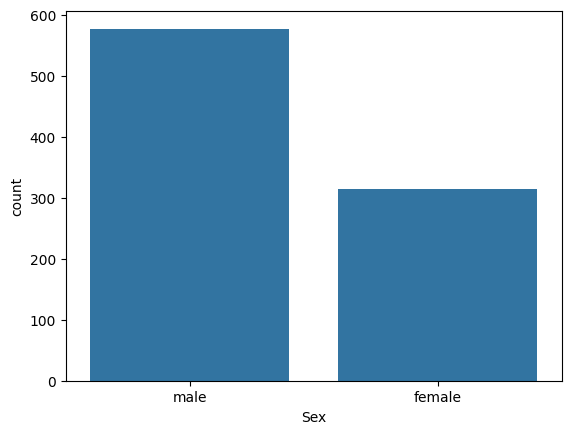

In [78]:
sns.countplot(df_titanic, x='Sex')

plt.show()

In [79]:
print(df_titanic['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


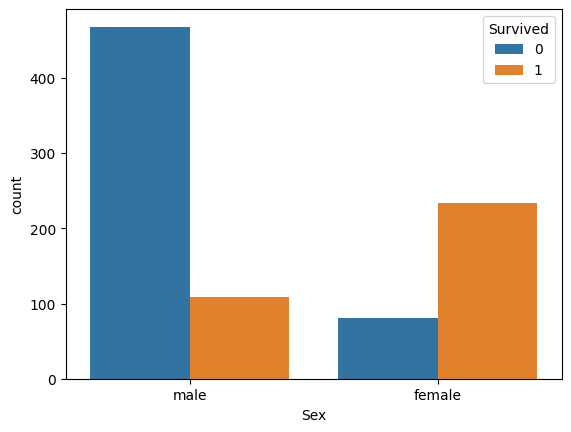

In [80]:
sns.countplot(df_titanic, x='Sex', hue='Survived')

plt.show()

In [81]:
print(pd.crosstab(df_titanic['Sex'], df_titanic['Survived']))

Survived    0    1
Sex               
female     81  233
male      468  109


Analisis:

Dari diagram di atas, dapat kita simpulkan bahwa jumlah penumpang wanita yang selamat jauh lebih banyak daripada penumpang pria. Sekitar 81% penumpang pria tidak selamat dan hanya sekitar 26% penumpang wanita yang tidak selamat.

**b) Usia (Kolom 'Age')**

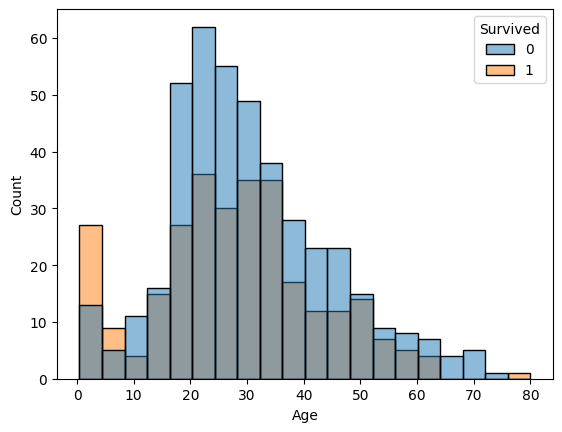

In [82]:
sns.histplot(df_titanic, x='Age', hue='Survived')

plt.show()

Analisis:

Dapat kita lihat, bahwa jumlah penumpang anak-anak yang selamat lebih banyak daripada orang dewasa. Rentang usia penumpangan antara 0-10 tahun memiliki probabilitas untuk selamat paling tinggi. Aturan *"Women and child first"* benar adanya.

##### **4) Korelasi Antar Semua Kolom Angka**

In [83]:
df_correlation_numbers_only = df_titanic.corr(numeric_only=True)

print(df_correlation_numbers_only)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


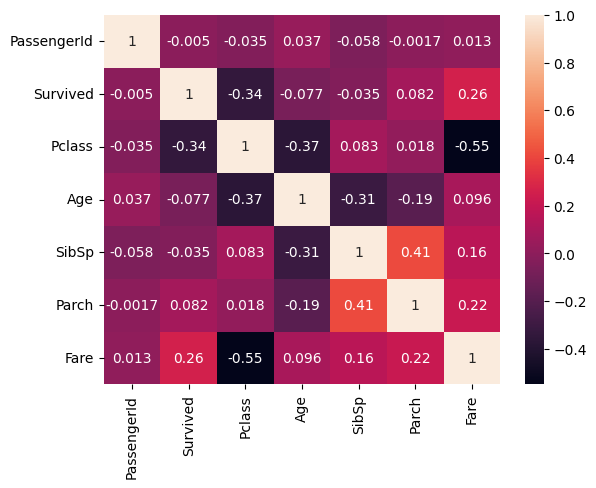

In [84]:
sns.heatmap(df_correlation_numbers_only, annot=True)

plt.show()

Analisis:

Dalam Heatmap Korelasi (Pearson Correlation), nilainya berkisar antar 1 dan -1:
* Mendekati 1 berarti korelasi kuat positif, jika data yang satu naik, data lainnya juga akan naik.
* Mendekati -1 berarti korelasi kuat negatif, jika data yang satu naik, data lainnya akan turun.
* Mendekati 0 berarti tidak ada korelasi.

Bisa kita lihat kolom 'Pclass' memiliki korelasi negatif yang cukup kuat dengan kolom target 'Survived'. Ini artinya penumpang dengan kelas tiket yang tinggi angkanya (kelas tiket 3 dalam arti kelas tiket yang paling rendah) memiliki kesempatan selamat yang rendah.

### **Data Preprocessing**

#### **Data Cleaning**

**Handling Missing Values**

---
Menangani nilai yang hilang/null/NaN (Not a Number) dengan cara menghapus atau mengisinya dengan sebuah nilai baru.

In [85]:
print(df_titanic.isnull().sum()) # isnull().sum() -> menghitung jumlah nilai null pada setiap kolom di dalam dataframe

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Analisis:

Dataset Titanic ini terdiri dari 12 kolom dengan total data sebanyak 891 data (dengan berbagai tipe data yang berbeda). Terdapat 3 kolom yang mempunyai nilai null, yaitu:
* Age: **19,86%** data hilang
* Cabin: **77,10%** data hilang
* Embarked: **0,22%** data hilang

---
Menangani missing values:

* Kolom Age -> Nilai yang hilang diisi dengan nilai tengah (Median) dari kolom tersebut. Hal ini dilakukan karena ada aturan tidak tertulis tentang "Anak-anak harus didahulukan", maka kolom Age ini penting untuk dipertahankan.
* Kolom Cabin -> Kolom ini dihapus, walaupun ada kemungkinan kolom ini bisa saja menentukan mana penumpang yang selamat atau tidak (posisi kamar penumpang bisa saja menunjukkan dek mana yang lebih dekat dengan sekoci). Tetapi karena kolom ini sudah terlalu rusak dengan lebih dari 77% data yang kosong/hilang dan daripada kita mengarang data sebanyak itu, maka pilihan yang bisa kita ambil adalah menghapus kolom ini.
* Kolom Embarked -> Hapus baris yang memiliki data yang kosong karena hanya ada 2 baris data saja yang memiliki nilai Embarked yang kosong (kurang dari 1% dari keseluruhan data), sehingga tidak akan terlalu berpengaruh jika dihapus.

**1) Menghapus kolom Cabin**

In [86]:
df_titanic.drop(columns='Cabin', inplace=True) # inplace=True -> menghapus langsung pada dataframe

**2) Menghapus baris yang memiliki nilai null pada kolom Embarked**

In [87]:
df_titanic.dropna(subset="Embarked", inplace=True)

**3) Mengisi nilai null pada kolom Age menggunakan median dari kolom tersebut**

In [88]:
median = df_titanic['Age'].median() # median() -> mengambil nilai tengah

df_titanic.fillna({'Age': median}, inplace=True)

In [89]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 83.3+ KB


In [90]:
print(df_titanic.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


#### **Feature Selection**
---
Memilih fitur mana saja yang akan digunakan atau yang dianggap paling berpengaruh terhadap goals yang ingin dicapai.

##### **1) Menghapus kolom yang tidak digunakan**

*Analisis:* Kolom PassengerId, Name dan Ticket tidak berpengaruh secara langsung terhadap keselamatan penumpang. Maka dari itu, ketiga kolom ini akan dihapus.

In [91]:
df_titanic.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [92]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    float64
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 62.5+ KB


##### **2) Encoding**

Mengubah data non-numerik (object) menjadi numerik (int64), sehingga data dapat dipelajari dan diproses oleh algoritma Machine Learning. Ada dua kolom yang perlu diubah, yaitu kolom Sex dan Embarked.

**a) Kolom 'Sex'**

In [93]:
try_sex_encoding = pd.get_dummies(df_titanic[['Sex']], dtype=int) # get_dummies -> one hot encoding

print(try_sex_encoding)

     Sex_female  Sex_male
0             0         1
1             1         0
2             1         0
3             1         0
4             0         1
..          ...       ...
886           0         1
887           1         0
888           1         0
889           0         1
890           0         1

[889 rows x 2 columns]


In [94]:
sex_encoding = pd.get_dummies(df_titanic[['Sex']], dtype=int, drop_first=True) # parameter drop_first -> menghemat memori agar tidak menyimpan informasi ganda. Jika sex_male = 1, maka otomatis sex_female = 0 dan sebaliknya

In [95]:
print(sex_encoding)

     Sex_male
0           1
1           0
2           0
3           0
4           1
..        ...
886         1
887         0
888         0
889         1
890         1

[889 rows x 1 columns]


In [96]:
df_titanic_encoding = pd.concat([df_titanic, sex_encoding], axis=1) # concat() -> menggabungkan dua dataframe

In [97]:
df_titanic_encoding.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_male
0,0,3,male,22.0,1,0,7.2500,S,1
1,1,1,female,38.0,1,0,71.2833,C,0
2,1,3,female,26.0,0,0,7.9250,S,0
3,1,1,female,35.0,1,0,53.1000,S,0
4,0,3,male,35.0,0,0,8.0500,S,1


In [98]:
df_titanic_encoding.drop(columns='Sex', inplace=True)

In [99]:
df_titanic_encoding.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Age       889 non-null    float64
 3   SibSp     889 non-null    int64  
 4   Parch     889 non-null    int64  
 5   Fare      889 non-null    float64
 6   Embarked  889 non-null    object 
 7   Sex_male  889 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 62.5+ KB


In [100]:
df_titanic_encoding.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male
0,0,3,22.0,1,0,7.2500,S,1
1,1,1,38.0,1,0,71.2833,C,0
2,1,3,26.0,0,0,7.9250,S,0
3,1,1,35.0,1,0,53.1000,S,0
4,0,3,35.0,0,0,8.0500,S,1


**b) Kolom 'Embarked'**

In [101]:
embarked_encoding = pd.get_dummies(df_titanic_encoding[['Embarked']], dtype=int, drop_first=True)

In [102]:
df_titanic_encoding_em = pd.concat([df_titanic_encoding, embarked_encoding], axis=1)

In [103]:
df_titanic_encoding_em.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Embarked,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,S,1,0,1
1,1,1,38.0,1,0,71.2833,C,0,0,0
2,1,3,26.0,0,0,7.9250,S,0,0,1
3,1,1,35.0,1,0,53.1000,S,0,0,1
4,0,3,35.0,0,0,8.0500,S,1,0,1


In [104]:
df_titanic_encoding_em.drop(columns='Embarked', inplace=True)

In [105]:
df_titanic_encoding_em.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,1
1,1,1,38.0,1,0,71.2833,0,0,0
2,1,3,26.0,0,0,7.9250,0,0,1
3,1,1,35.0,1,0,53.1000,0,0,1
4,0,3,35.0,0,0,8.0500,1,0,1


In [106]:
df_titanic_encoding_em.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    889 non-null    int64  
 1   Pclass      889 non-null    int64  
 2   Age         889 non-null    float64
 3   SibSp       889 non-null    int64  
 4   Parch       889 non-null    int64  
 5   Fare        889 non-null    float64
 6   Sex_male    889 non-null    int64  
 7   Embarked_Q  889 non-null    int64  
 8   Embarked_S  889 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 69.5 KB


In [107]:
df_titanic_encoding_em.corr()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
Survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290,-0.541585,0.004536,-0.151777
Pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193,0.127741,0.220558,0.076466
Age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707,0.086506,-0.030436,-0.008964
SibSp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887,-0.116348,-0.026692,0.069438
Parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532,-0.247508,-0.081585,0.061512
Fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000,-0.179958,-0.116684,-0.163758
Sex_male,-0.541585,0.127741,0.086506,-0.116348,-0.247508,-0.179958,1.000000,-0.075217,0.121405
Embarked_Q,0.004536,0.220558,-0.030436,-0.026692,-0.081585,-0.116684,-0.075217,1.000000,-0.499261
Embarked_S,-0.151777,0.076466,-0.008964,0.069438,0.061512,-0.163758,0.121405,-0.499261,1.000000


#### **Splitting & Scaling**
---
Memisahkan variabel input dengan variabel target, memisahkan data latih dengan data uji, serta menyamakan skala setiap data.

##### **1) Data Splitting**

**a) Memisahkan variabel input dengan variabel target**

In [108]:
y = df_titanic_encoding_em['Survived']

print(y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 889, dtype: int64


In [109]:
X = df_titanic_encoding_em.drop(columns='Survived')

print(X)

     Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S
0         3  22.0      1      0   7.2500         1           0           1
1         1  38.0      1      0  71.2833         0           0           0
2         3  26.0      0      0   7.9250         0           0           1
3         1  35.0      1      0  53.1000         0           0           1
4         3  35.0      0      0   8.0500         1           0           1
..      ...   ...    ...    ...      ...       ...         ...         ...
886       2  27.0      0      0  13.0000         1           0           1
887       1  19.0      0      0  30.0000         0           0           1
888       3  28.0      1      2  23.4500         0           0           1
889       1  26.0      0      0  30.0000         1           0           0
890       3  32.0      0      0   7.7500         1           1           0

[889 rows x 8 columns]


**b) Memisahkan data latih dengan data uji**

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [112]:
print(y_train)

708    1
240    0
382    0
792    0
683    0
      ..
107    1
271    1
862    1
436    0
103    0
Name: Survived, Length: 711, dtype: int64


##### **2) Data Scaling**

In [113]:
from sklearn.preprocessing import StandardScaler

In [114]:
scale = StandardScaler()

X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

* fit() -> menghitung rata-rata dan standar deviasi dari data
* transform() -> menerapkannya
* fit_transform() -> komputer mempelajari datanya dan menyesuaikannya

Kita menggunakan rata-rata dan standar deviasi milik Training Set untuk men-skalakan Test Set. Test set harus diperlakukan seolah-olah data asing yang belum pernah dilihat sebelumnya.

In [115]:
print(X_train_scaled)

[[-1.58410418 -0.57186777 -0.47451561 ... -1.40530972 -0.31720529
   0.61908681]
 [ 0.8122747  -0.11508796  0.38178033 ... -1.40530972 -0.31720529
  -1.61528235]
 [ 0.8122747   0.18943192 -0.47451561 ...  0.71158691 -0.31720529
   0.61908681]
 ...
 [-1.58410418  1.40751143 -0.47451561 ... -1.40530972 -0.31720529
   0.61908681]
 [ 0.8122747  -0.64799774  1.23807626 ... -1.40530972 -0.31720529
   0.61908681]
 [ 0.8122747   0.26556189 -0.47451561 ...  0.71158691 -0.31720529
   0.61908681]]


## **Building Models**
---
Membangun beberapa model untuk memprediksi mana penumpang yang selamat dan mana yang tidak. Kemudian, kita bandingkan performa dari model-model tersebut dan menentukan mana yang terbaik.

### **1) Logistic Regression**

Menghitung probabilitas suatu data masuk ke kelas tertentu (ya/tidak). Langkah-langkah algoritma Logistic Regression:
1. Fase Training
    * Inisialisasi: Bobot (*m*) dan Bias (*b*)
    * Hitung fungsi garis lurus: *z = mx + b*
    * Hitung nilai *z* dengan fungsi Sigmoid
    * Hitung Error (Cost Function): Bandingkan nilai *z* asli dengan nilai *z* yang diprediksi. Jika prediksinya jauh dari aslinya, errornya besar dan sebaliknya.
    * Update (Gradient Descent): Komputer memperbarui nilai *m* dan *b* sedikit demi sedikit.
    * Looping: Ulangi langkah 2-4 hingga mendapatkan nilai *m* dan *b* yang optimal.
2. Fase Testing
    * Input data baru
    * Hitung probabilitas: Hitung fungsi garis lurus menggunakan nilai *m* dan *b* yang sudah diperoleh dari fase training dan hitung probabilitas menggunakan fungsi Sigmoid.
    * Ambil keputusan (Thresholding): Jika probabilitas data baru di atas threshold, maka hasilnya positif dan sebaliknya.


In [116]:
from sklearn import linear_model

**a) Melatih Model Logistic Regression**

In [117]:
lr = linear_model.LogisticRegression()

lr.fit(X_train_scaled, y_train)

LogisticRegression()

**b) Menguji Model**

In [118]:
y_pred = lr.predict(X_test_scaled)

**c) Menampilkan Confusion Matrix**


In [119]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

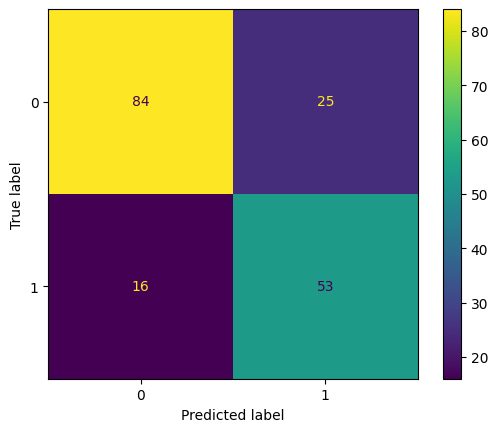

In [120]:
cm = confusion_matrix(y_test, y_pred)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
cm_display.plot()
plt.show()

Keterangan:

1. *True Negative:* Jumlah penumpang tidak selamat dan diprediksi benar/tidak selamat oleh model -> sebanyak 84 penumpang.
2. *False Negative:* Jumlah penumpang selamat, tetapi diprediksi tidak selamat oleh model -> sebanyak 16 penumpang.
3. *False Positive:* Jumlah penumpang tidak selamat, tetapi diprediksi selamat oleh model -> sebanyak 25 penumpang.
4. *True Positive:* Jumlah penumpang selamat dan diprediksi benar/selamat oleh model -> sebanyak 53 penumpang.
---
Terlihat bahwa jumlah *False Positive* lebih banyak dari *False Negative*, artinya model sedikit terlalu optimis memprediksi orang akan selamat.

**d) Menghitung Akurasi/Accuracy**

Menghitung seberapa sering model benar.



In [121]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [122]:
print(f"Hasil akurasi model sebesar: {accuracy_score(y_test, y_pred)}")

Hasil akurasi model sebesar: 0.7696629213483146


**e) Menghitung Presisi/Precision**

Dari semua yang diprediksi positif, mana yang benar-benar positif?

In [123]:
print(f"Hasil precision model sebesar: {precision_score(y_test, y_pred)}")

Hasil precision model sebesar: 0.6794871794871795


**f) Menghitung Sensitivitas/Recall**

Dari semua kejadian positif yang ada di dunia nyata, berapa yang berhasil ditemukan?

In [124]:
print(f"Hasil recall model sebesar: {recall_score(y_test, y_pred)}")

Hasil recall model sebesar: 0.7681159420289855


### **2) Random Forest**
Kumpulan dari banyak Pohon Keputusan (Decision Tree).

In [125]:
from sklearn.ensemble import RandomForestClassifier

**a) Melatih Model Random Forest**

In [126]:
rf = RandomForestClassifier(random_state=42)

In [127]:
rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

**b) Menguji Model Random Forest**

In [128]:
y_pred_rf = rf.predict(X_test_scaled)

**c) Menampilkan Confusion Matrix**

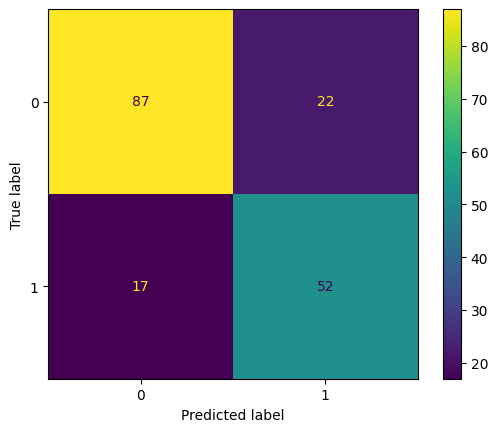

In [129]:
cm = confusion_matrix(y_test, y_pred_rf)

cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
cm_display.plot()
plt.show()

Keterangan:

1. *True Negative:* Jumlah penumpang tidak selamat dan diprediksi benar/tidak selamat oleh model -> sebanyak 87 penumpang.
2. *False Negative:* Jumlah penumpang selamat, tetapi diprediksi tidak selamat oleh model -> sebanyak 17 penumpang.
3. *False Positive:* Jumlah penumpang tidak selamat, tetapi diprediksi selamat oleh model -> sebanyak 22 penumpang.
4. *True Positive:* Jumlah penumpang selamat dan diprediksi benar/selamat oleh model -> sebanyak 52 penumpang.
---
Terlihat bahwa jumlah *False Positive* lebih banyak dari *False Negative*, artinya model sedikit terlalu optimis memprediksi orang akan selamat.

**d) Menghitung Metrik dari Model Random Forest**

In [130]:
print(f"Hasil akurasi model sebesar: {accuracy_score(y_test, y_pred_rf)}")
print(f"Hasil precision model sebesar: {precision_score(y_test, y_pred_rf)}")
print(f"Hasil recall model sebesar: {recall_score(y_test, y_pred_rf)}")

Hasil akurasi model sebesar: 0.7808988764044944
Hasil precision model sebesar: 0.7027027027027027
Hasil recall model sebesar: 0.7536231884057971


Kesimpulan:

Model Random Forest menghasilkan akurasi yang sedikit lebih baik daripada model Logistic Regression, yaitu kurang lebih sebesar 78%. Dengan nilai precision dan recall kurang lebih sebesar 70% dan 75%.